# 6.2 Exploring Relationships

### 1. Importing Visualization Libraries and Data

In [3]:
# importing libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib
import os

In [19]:
matplotlib.__version__

'3.9.2'

In [91]:
%matplotlib inline

In [5]:
# creating path
path = r'C:\Users\jeffr\Documents\Medical Costs Analysis'

In [11]:
# importing insurance data set
df = pd.read_csv(os.path.join(path, '02 Data', 'Prepared Data', 'insurance.csv'), index_col = False)

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1337 entries, 0 to 1336
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  1337 non-null   int64  
 1   age         1337 non-null   int64  
 2   sex         1337 non-null   object 
 3   bmi         1337 non-null   float64
 4   children    1337 non-null   int64  
 5   smoker      1337 non-null   object 
 6   region      1337 non-null   object 
 7   charges     1337 non-null   float64
dtypes: float64(2), int64(3), object(3)
memory usage: 83.7+ KB


In [15]:
df.head()

,Unnamed: 0,age,sex,bmi,children,smoker,region,charges
0,0,19,female,27.900,0,yes,southwest,16884.92400
1,1,18,male,33.770,1,no,southeast,1725.55230
2,2,28,male,33.000,3,no,southeast,4449.46200
3,3,33,male,22.705,0,no,northwest,21984.47061
4,4,32,male,28.880,0,no,northwest,3866.85520


## Create a Correlation Matrix Heatmap

In [27]:
df.columns

Index(['Unnamed: 0', 'age', 'sex', 'bmi', 'children', 'smoker', 'region',
       'charges'],
      dtype='object')

In [29]:
df.reset_index(drop=True, inplace=True)

In [31]:

df.head()

,Unnamed: 0,age,sex,bmi,children,smoker,region,charges
0,0,19,female,27.900,0,yes,southwest,16884.92400
1,1,18,male,33.770,1,no,southeast,1725.55230
2,2,28,male,33.000,3,no,southeast,4449.46200
3,3,33,male,22.705,0,no,northwest,21984.47061
4,4,32,male,28.880,0,no,northwest,3866.85520


In [35]:
# drop Unnamed:0 column
df=df.drop(columns=['Unnamed: 0'])

In [37]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [45]:
# creating a subset with only numerica; variables
sub = df[['age', 'bmi', 'children', 'charges']]

In [47]:
sub.columns

Index(['age', 'bmi', 'children', 'charges'], dtype='object')

In [51]:
sub.corr()

,age,bmi,children,charges
age,1.000000,0.109344,0.041536,0.298308
bmi,0.109344,1.000000,0.012755,0.198401
children,0.041536,0.012755,1.000000,0.067389
charges,0.298308,0.198401,0.067389,1.000000


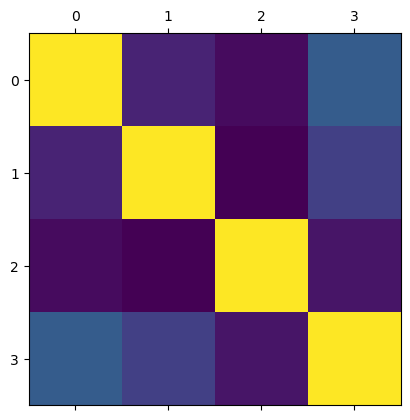

In [53]:
plt.matshow(sub.corr())
plt.show()

In [59]:
# save figure
plt.matshow(sub.corr())
plt.savefig(os.path.join(path, '04 Analysis', 'Visualizations', 'sub.corr1.png'))

In [75]:
# add labels and legend and adjust size
f = plt.figure(figsize=(8, 8))
plt.matshow(sub.corr(), fignum=f.number)
plt.xticks(range(sub.shape[1]), sub.columns, fontsize=14, rotation=45)
plt.yticks(range(sub.shape[1]), sub.columns, fontsize=14)
cb = plt.colorbar()
cb.ax.tick_params(labelsize=14)
plt.title('Correlation Matrix', fontsize=14)

Text(0.5, 1.0, 'Correlation Matrix')

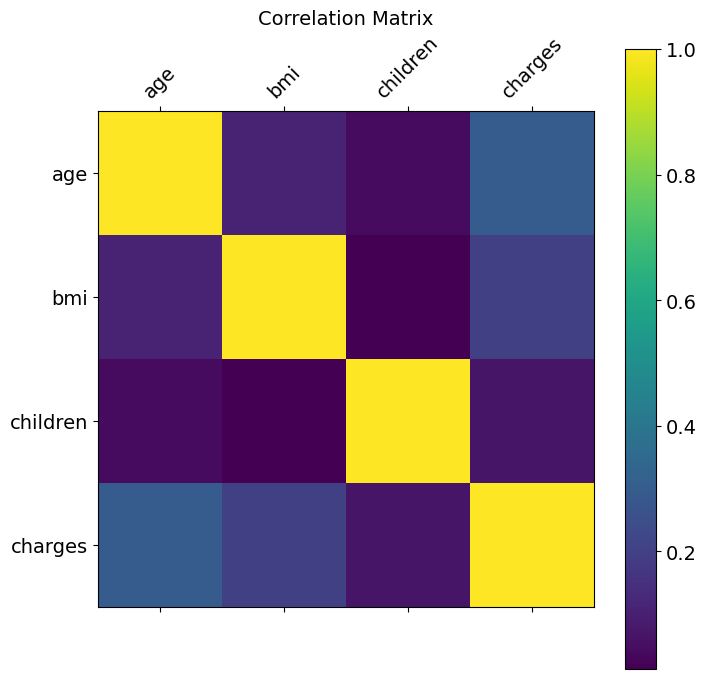

In [77]:
plt.show()

### All variables have a positive correlation. The yellow is a 1-to-1 relationship between the same variable. The second strongest correlation appears to be between age and charges, next to that bmi and charges. The weakest correlation appears to be between bmi and children.

## Create a scatterplot for the variables with the strongest correlations

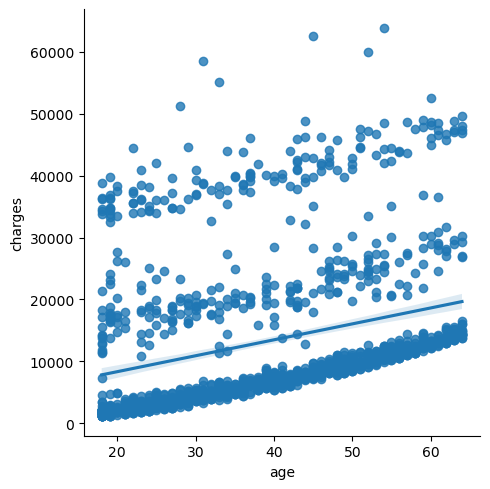

In [99]:
# creating scatterplot for "charges" and "age" columns in seaborn
sns.lmplot(x = 'age', y = 'charges', data = sub)
plt.show()

### There is definitely a strong correlation between charges and age. The scatterplot created what appears to be 3 different clusters that follow the trend line.  Each show charges increasing with age.

## Creat a pair plot of the entire data set

In [103]:
# Creating pair plots using subset
g = sns.pairplot(sub)

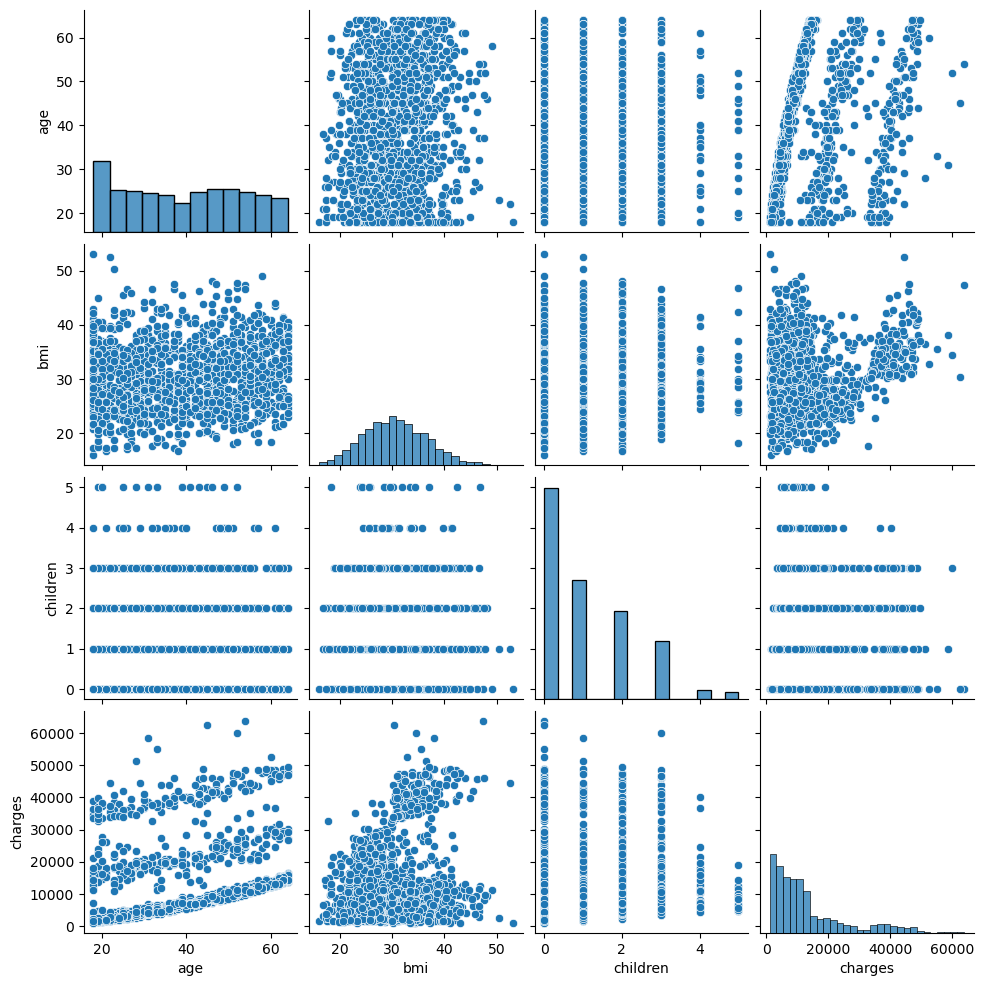

In [105]:
plt.show()

Based on the results of the pair plots, majority of those with children dependants of all ages appear to be between 0-2 and then starts to decrease from 3 and above. Bit surprised that there really doesn't appear to be a correlation between BMI and the other variables, except there is a cluster of those with a 30-40 BMI that have charges between 3000-5000.  The one plot pair I found interesting was that between number of children dependants and charges. Those with 4-5 children have less charges. I would like to explore this further since I would think the more children would mean more medical charges due to preventive childhood appointments.

## Create a categorical plot and interpret results

In [109]:
# Creating a categorical plot using "charges" variable
sns.histplot(df['charges'], bins = 20, kde = True)

<Axes: xlabel='charges', ylabel='Count'>

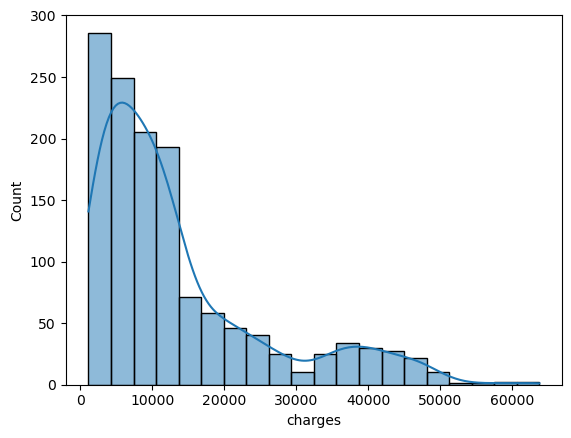

In [111]:
plt.show()

### Majority of medical charges are between 0-1500 at which it drops significantly. From 1500-3000 it continues to drop and then slightly increases from around 3300-5000.  This parallels the scatterplot from above in which there were clear distinctions of charge groupings.

## Merge US region dataframe into existing dataset

In [121]:
# Importing regions data set
df_reg = pd.read_json(os.path.join(path, '02 Data', 'Original Data', 'regions'))

In [137]:
df_reg.head()

,type,features
0,FeatureCollection,"{'type': 'Feature', 'properties': {'name': 'Mi..."
1,FeatureCollection,"{'type': 'Feature', 'properties': {'name': 'No..."
2,FeatureCollection,"{'type': 'Feature', 'properties': {'name': 'So..."
3,FeatureCollection,"{'type': 'Feature', 'properties': {'name': 'We..."


Not sure what I am to do here.  